##Environment Setup & Data Loading
First, mount Google Drive and import necessary libraries:



In [ ]:
# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Load the dataset containing clean and noisy patient symptom descriptions into a pandas DataFrame:

In [ ]:
import pandas as pd

# Set the path to your dataset in Google Drive
file_path = "/content/drive/MyDrive/Train_data_with_noise2.csv"  # Adjust this path if needed

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to check the data
print(f"Cleaned dataset shape: {df.shape}")
df.head()


Cleaned dataset shape: (1200, 5)


,Unnamed: 0,label,text,medium_noise,heavy_noise
0,50,Varicose Veins,I have a rash on my legs that is causing a lot...,"""Oh dear... I've got this rash on my legs, you...",Oh dear doctor... I'm so glad you're here. You...
1,51,Varicose Veins,My calves have been cramping up when I walk or...,My calves have been crampin' up somethin' fier...,"Oh boy, doc... my calves, you see... they've b..."
2,52,Varicose Veins,There is bruising on my legs that I cannot exp...,"""Doc... or is it nurse? Anyway, I'm concerned ...",I don't know what's goin' on with these bruise...
3,53,Varicose Veins,I am overweight and have noticed that my legs ...,"You know, I was just at the Early Bird Special...","Oh dear... legs, yes... swellin' up somethin' ..."
4,54,Varicose Veins,The veins on my calves have become very promin...,"""Doc... I think it started... um... how long a...","I don't know if I'm explainin' this right, but..."


##Data Cleaning and Preparation
Perform basic cleaning steps to ensure data quality

In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

# Remove rows with any missing values
df = df.dropna()

# Reset index after cleaning
df = df.reset_index(drop=True)

# Show the updated shape and first few rows
print(f"Cleaned dataset shape: {df.shape}")
df.head()


Cleaned dataset shape: (1200, 5)


,Unnamed: 0,label,text,medium_noise,heavy_noise
0,50,Varicose Veins,I have a rash on my legs that is causing a lot...,"""Oh dear... I've got this rash on my legs, you...",Oh dear doctor... I'm so glad you're here. You...
1,51,Varicose Veins,My calves have been cramping up when I walk or...,My calves have been crampin' up somethin' fier...,"Oh boy, doc... my calves, you see... they've b..."
2,52,Varicose Veins,There is bruising on my legs that I cannot exp...,"""Doc... or is it nurse? Anyway, I'm concerned ...",I don't know what's goin' on with these bruise...
3,53,Varicose Veins,I am overweight and have noticed that my legs ...,"You know, I was just at the Early Bird Special...","Oh dear... legs, yes... swellin' up somethin' ..."
4,54,Varicose Veins,The veins on my calves have become very promin...,"""Doc... I think it started... um... how long a...","I don't know if I'm explainin' this right, but..."


Analyze how adding noise affects the length of patient descriptions. This helps to better understand the differences between clean and noisy datasets.

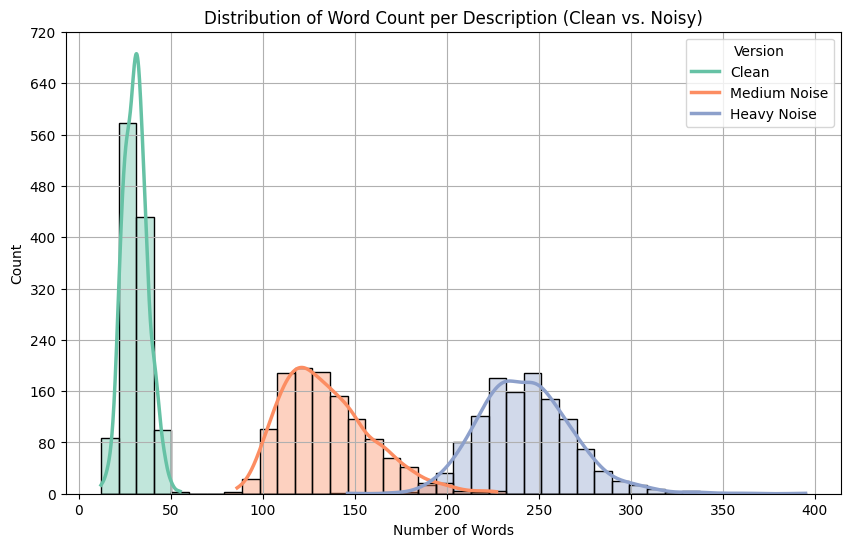

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde
from matplotlib.ticker import MaxNLocator
import pandas as pd

# Compute word counts and convert to numeric type
clean_lengths = df["text"].apply(lambda x: len(str(x).split()))
medium_lengths = df["medium_noise"].apply(lambda x: len(str(x).split()))
heavy_lengths = df["heavy_noise"].apply(lambda x: len(str(x).split()))

# Create a long-form DataFrame for the histogram
df_long = pd.DataFrame({
    "Clean": clean_lengths,
    "Medium Noise": medium_lengths,
    "Heavy Noise": heavy_lengths
}).melt(var_name="Version", value_name="Word_Count")

# Initialize the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Plot histogram on count scale
sns.histplot(
    data=df_long,
    x="Word_Count",
    hue="Version",
    palette="Set2",
    bins=40,
    alpha=0.4,
    stat="count",
    ax=ax
)

# Calculate bin width for KDE scaling
min_x, max_x = df_long["Word_Count"].min(), df_long["Word_Count"].max()
bin_edges = np.linspace(min_x, max_x, 41)  # 40 bins => 41 edges
bin_width = bin_edges[1] - bin_edges[0]

# Overlay thick KDE curves for each category
colors = sns.color_palette("Set2")
for lengths, label, color in zip(
    [clean_lengths, medium_lengths, heavy_lengths],
    ["Clean", "Medium Noise", "Heavy Noise"],
    colors
):
    data = lengths.dropna()
    kde = gaussian_kde(data)
    x_min, x_max = data.min(), data.max()
    x_grid = np.linspace(x_min, x_max, 500)
    y_counts = kde(x_grid) * len(data) * bin_width
    ax.plot(
        x_grid,
        y_counts,
        label=label,
        color=color,
        linewidth=2.5  # Thicken the KDE line
    )

# Final plot formatting
ax.set_title("Distribution of Word Count per Description (Clean vs. Noisy)")
ax.set_xlabel("Number of Words")
ax.set_ylabel("Count")
ax.grid(True)
ax.legend(title="Version")
ax.yaxis.set_major_locator(MaxNLocator(integer=True))  # Use integer tick values on y-axis

plt.show()


##Multinomial Naive Bayes Classifier (Baseline Model)
This section demonstrates a baseline classification model (Multinomial Naive Bayes) using TF-IDF vectorization. The goal is to analyze how classification performance varies with different noise levels in symptom descriptions.

Steps include: Encoding labels into numeric format, Consistent stratified train-test split for fair comparison across noise levels, TF-IDF vectorization of text data, Training and evaluating the model for three distinct noise levels: Clean (no noise), Medium Noise and Heavy Noise


###Label Encoding
Convert textual disease labels to numeric format for modeling

In [ ]:
# Encode labels (text → int)
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoder.fit(df["label"])  # fit on full label list
df["label"] = encoder.transform(df["label"])  # apply encoding to full dataset

In [ ]:
label_map = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
reverse_label_map = dict(zip(encoder.transform(encoder.classes_), encoder.classes_))

###Model Training & Evaluation
The model is trained separately for each noise level, using the same train-test split to ensure consistent comparisons

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd

# Define the text columns for each noise level
noise_levels = {
    "Clean": "text",
    "Medium Noise": "medium_noise",
    "Heavy Noise": "heavy_noise"
}

# Set random state for reproducibility
RANDOM_STATE = 42

labels = []
accuracies = []

# Generate one split to be reused across all noise levels
X_full = df["text"]
y_full = df["label"]

X_train_idx, X_test_idx, y_train, y_test = train_test_split(
    X_full.index, y_full, test_size=0.2, random_state=RANDOM_STATE, stratify=y_full
)

# Iterate over each noise level and use the same split
for level_name, col_name in noise_levels.items():
    print(f"\n=== {level_name} ===")

    # Get the noisy versions of the text
    X = df[col_name]

    # Apply the same split
    X_train = X.loc[X_train_idx]
    X_test = X.loc[X_test_idx]

    # Vectorize text using TF-IDF
    vect = TfidfVectorizer()
    X_train_tfidf = vect.fit_transform(X_train)
    X_test_tfidf = vect.transform(X_test)

    # Train Multinomial Naive Bayes
    clf = MultinomialNB()
    clf.fit(X_train_tfidf, y_train)

    # Predict and evaluate
    y_pred = clf.predict(X_test_tfidf)
    acc = accuracy_score(y_test, y_pred)

    labels.append(level_name)
    accuracies.append(acc)

    print(f"Accuracy: {acc:.3f}")
    print(classification_report(y_test, y_pred, zero_division=0))


=== Clean ===
Accuracy: 0.938
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.91      1.00      0.95        10
           2       1.00      1.00      1.00        10
           3       0.91      1.00      0.95        10
           4       0.89      0.80      0.84        10
           5       0.91      1.00      0.95        10
           6       0.90      0.90      0.90        10
           7       1.00      1.00      1.00        10
           8       0.91      1.00      0.95        10
           9       1.00      0.90      0.95        10
          10       1.00      1.00      1.00        10
          11       0.83      1.00      0.91        10
          12       1.00      1.00      1.00        10
          13       1.00      0.90      0.95        10
          14       0.71      1.00      0.83        10
          15       1.00      0.90      0.95        10
          16       0.91      1.00      0.95       

###Visualization: Accuracy Comparison Across Noise Levels
Clearly visualize how accuracy deteriorates as noise increases in the symptom descriptions

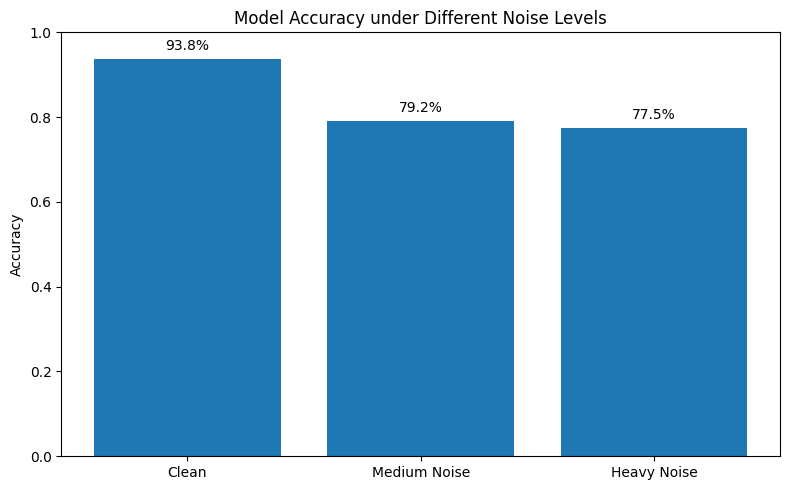

In [ ]:
# Plot the bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(labels, accuracies)
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy under Different Noise Levels')

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, acc + 0.02,
             f"{acc * 100:.1f}%", ha='center')

plt.tight_layout()
plt.show()

## Fine-tuned BERT Model with AdamP Optimizer
This section details the implementation of a fine-tuned BERT model using the AdamP optimizer, aiming to classify patient-reported symptoms. It evaluates how the model’s performance varies under different noise conditions.

Key points:
* Fine-tuned BERT (uncased-base model)
* AdamP optimizer for convergence and training stability
* Layer freezing (initial four encoder layers) to improve computational efficiency and mitigate overfitting
* Consistent stratified data split across noise conditions for accurate comparison.




###Setup and Dependencies

In [ ]:
!pip install adamp datasets

  Preparing metadata (setup.py) ... done
  Created wheel for adamp: filename=adamp-0.3.0-py3-none-any.whl size=5981 sha256=f7c2485d8335d9bc62be70dd7367d321f5f287c583ee2b61650ebd251fdc9eb8
  Stored in directory: /root/.cache/pip/wheels/33/f9/d6/b2ed816e1f321f6dcf72a99c954223b1259477095f40434979
Successfully built adamp


In [ ]:
!pip install "numpy<2.0"

###Tokenization & Helper Functions
Define necessary functions for tokenization, accuracy calculation, and batching

In [ ]:
import os
import torch
from datasets import Dataset
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
)
from torch.utils.data import DataLoader
from adamp import AdamP
from sklearn.metrics import accuracy_score
import numpy as np

# Setup
MODEL_NAME = "bert-base-uncased"
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
NUM_LABELS = df["label"].nunique()

# Tokenization function
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=512)

# Accuracy function
def compute_accuracy(preds, labels):
    return (preds == labels).mean()

# Custom collate function
def my_collate_fn(batch):
    return {
        'input_ids': torch.stack([x['input_ids'] for x in batch]),
        'attention_mask': torch.stack([x['attention_mask'] for x in batch]),
        'labels': torch.tensor([x['label'] for x in batch])
    }

### Noise Levels & Training Settings & Model Training Loop
Iterate through each noise level and train the model

In [ ]:
# Define noise levels and epochs
noise_levels = {
    "Clean": {"col": "text", "epochs": 4},
    "Medium Noise": {"col": "medium_noise", "epochs": 6},
    "Heavy Noise": {"col": "heavy_noise", "epochs": 8}
}

# dicts to store histories and final accuracies
train_acc_history = {}
val_acc_history = {}

# Loop over noise levels
for level_name, settings in noise_levels.items():
    col_name = settings["col"]
    num_epochs = settings["epochs"]
    batch_size = 8

    # lists to collect accuracies this run
    train_list = []
    val_list   = []

    print(f"\n=== BERT+AdamP ({level_name}) | Epochs: {num_epochs} ===")

    # Prepare train/test DataFrames
    df_tr = (df.loc[X_train_idx, [col_name, "label"]]
             .rename(columns={col_name: "text"})
             .copy())
    df_te = (df.loc[X_test_idx, [col_name, "label"]]
             .rename(columns={col_name: "text"})
             .copy())
    df_tr["label"] = df_tr["label"].astype(int)
    df_te["label"] = df_te["label"].astype(int)

    # Convert to Dataset + tokenize
    ds_tr = (Dataset.from_pandas(df_tr, preserve_index=False)
             .map(tokenize_batch, batched=True))
    ds_te = (Dataset.from_pandas(df_te, preserve_index=False)
             .map(tokenize_batch, batched=True))
    ds_tr.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    ds_te.set_format("torch", columns=["input_ids", "attention_mask", "label"])

    # DataLoaders with custom collate_fn
    train_loader = DataLoader(ds_tr, batch_size=batch_size, shuffle=True, collate_fn=my_collate_fn)
    val_loader = DataLoader(ds_te, batch_size=batch_size, shuffle=False, collate_fn=my_collate_fn)

    # Model
    model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS).to(device)
    # Freeze early encoder layers
    for name, param in model.named_parameters():
      if name.startswith("bert.encoder.layer"):
        layer_idx = int(name.split(".")[3])
        if layer_idx < 4:
            param.requires_grad = False
    # optimizer
    optimizer = AdamP(model.parameters(), lr=5e-5, weight_decay=0.01)

    # Create output directory for saving checkpoints
    output_dir = f"./bert_checkpoints_{level_name.lower().replace(' ', '_')}"
    os.makedirs(output_dir, exist_ok=True)

    # Training loop
    for epoch in range(1, num_epochs + 1):
        model.train()
        train_preds, train_labels = [], []

        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            last_train_loss = loss.item()
            train_preds.extend(torch.argmax(logits, axis=1).cpu().numpy())
            train_labels.extend(batch["labels"].cpu().numpy())

        train_acc = compute_accuracy(np.array(train_preds), np.array(train_labels))
        train_list.append(train_acc)

        model.eval()
        val_preds, val_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)
                loss = outputs.loss
                logits = outputs.logits

                last_val_loss = loss.item()
                val_preds.extend(torch.argmax(logits, axis=1).cpu().numpy())
                val_labels.extend(batch["labels"].cpu().numpy())

        val_acc = compute_accuracy(np.array(val_preds), np.array(val_labels))
        val_list.append(val_acc)

        print(
            f"Epoch {epoch}/{num_epochs} - "
            f"loss: {last_train_loss:.4f} - acc: {train_acc:.4f} - "
            f"val_loss: {last_val_loss:.4f} - val_acc: {val_acc:.4f}"
        )

        # Save model weights after each epoch
        checkpoint_dir = os.path.join(output_dir, f"epoch_{epoch}")
        model.save_pretrained(checkpoint_dir)

    # store histories
    train_acc_history[level_name] = train_list
    val_acc_history[level_name]   = val_list

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

...

Epoch 1/6 - loss: 2.5930 - acc: 0.0688 - val_loss: 2.4172 - val_acc: 0.3792
Epoch 2/6 - loss: 1.4941 - acc: 0.5969 - val_loss: 1.2156 - val_acc: 0.7333
Epoch 3/6 - loss: 0.9455 - acc: 0.8427 - val_loss: 0.4796 - val_acc: 0.8667
Epoch 4/6 - loss: 0.1691 - acc: 0.9500 - val_loss: 0.4229 - val_acc: 0.8167
Epoch 5/6 - loss: 0.1144 - acc: 0.9844 - val_loss: 0.2847 - val_acc: 0.9042
Epoch 6/6 - loss: 0.0348 - acc: 0.9917 - val_loss: 0.2925 - val_acc: 0.9000

=== BERT+AdamP (Heavy Noise) | Epochs: 8 ===


Map:   0%|          | 0/960 [00:00<?, ? examples/s]

Map:   0%|          | 0/240 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/8 - loss: 2.8012 - acc: 0.0708 - val_loss: 2.5550 - val_acc: 0.2792
Epoch 2/8 - loss: 0.8620 - acc: 0.4792 - val_loss: 1.6070 - val_acc: 0.6958
Epoch 3/8 - loss: 0.8188 - acc: 0.7656 - val_loss: 0.9849 - val_acc: 0.7917
Epoch 4/8 - loss: 0.7396 - acc: 0.9042 - val_loss: 0.5277 - val_acc: 0.8125
Epoch 5/8 - loss: 0.2236 - acc: 0.9542 - val_loss: 0.3961 - val_acc: 0.8500
Epoch 6/8 - loss: 0.0783 - acc: 0.9792 - val_loss: 0.3448 - val_acc: 0.8667
Epoch 7/8 - loss: 0.0557 - acc: 0.9906 - val_loss: 0.2114 - val_acc: 0.8625
Epoch 8/8 - loss: 0.0371 - acc: 0.9927 - val_loss: 0.0652 - val_acc: 0.9167


### Accuracy Visualization
Visualize the best validation accuracy under different noise levels (limited to ≤ 5% overfitting gap)

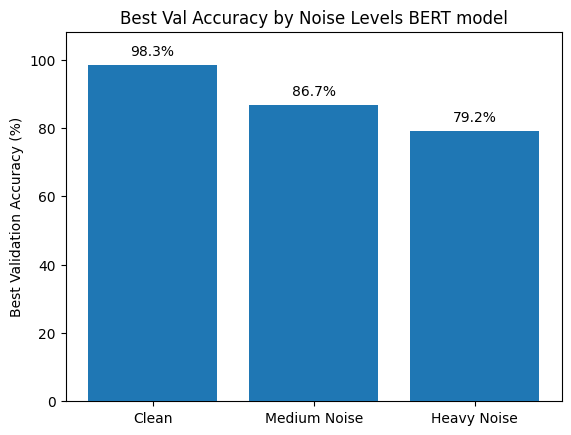

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

best_acc_by_level = {}
max_allowed_gap = 0.05  # maximum allowed overfitting gap (5%)

for level, val_list in val_acc_history.items():
    train_list = train_acc_history[level]
    # compute the overfitting gap for each epoch (train_acc − val_acc)
    gaps = [t - v for t, v in zip(train_list, val_list)]
    # select only those epochs where the gap does not exceed the threshold
    candidates = [i for i, g in enumerate(gaps) if g <= max_allowed_gap]
    if not candidates:
        # if none meet the gap criterion, fall back to considering all epochs
        candidates = list(range(len(val_list)))
    # among the candidates, pick the epoch with the highest validation accuracy
    best_idx = max(candidates, key=lambda i: val_list[i])
    # store the best validation accuracy (as a percentage)
    best_acc_by_level[level] = val_list[best_idx] * 100

labels = list(best_acc_by_level.keys())
values = list(best_acc_by_level.values())

fig, ax = plt.subplots()

# draw bars
bars = ax.bar(labels, values)

# add 10% margin on y-axis so labels stay inside the frame
ax.margins(y=0.1)

# annotate each bar just above its top, inside the axes area
for bar, v in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,  # x: center of bar
        v + (max(values) * 0.02),           # y: just above bar top, using 2% of max height
        f"{v:.1f}%",                        # text: percentage
        ha='center',                        # horizontal align center
        va='bottom',                        # vertical align bottom
        zorder=3                            # draw text on top of everything
    )

# move spines (axes frame) behind bars and text
for spine in ax.spines.values():
    spine.set_zorder(0)

ax.set_ylim(0, None)               # allow top margin from ax.margins()
ax.set_ylabel("Best Validation Accuracy (%)")
ax.set_title("Best Val Accuracy by Noise Levels BERT model")

plt.show()

## Fine-tuning ClinicalBERT Model (AdamP & Scheduler)
This section covers the fine-tuning of ClinicalBERT, a model specifically pretrained on clinical notes, optimized using AdamP along with a linear warm-up scheduler. This setup aims to leverage the specialized knowledge embedded in ClinicalBERT to accurately classify noisy medical symptom descriptions.

Key Features:

* Specialized ClinicalBERT pretrained on medical data.
* AdamP optimizer with weight decay for stable convergence.
* Linear learning rate scheduler with warm-up steps.
* Strategic parameter freezing for efficient and stable training.


### Model and Utilities Setup
Define tokenizer, model loading, and helper functions

In [ ]:
import os
import torch
from datasets import Dataset
from transformers import (
    BertTokenizerFast,
    BertForSequenceClassification,
)
from torch.utils.data import DataLoader
from adamp import AdamP
from sklearn.metrics import accuracy_score
import numpy as np
from transformers import get_linear_schedule_with_warmup

# Setup
MODEL_NAME = "emilyalsentzer/Bio_ClinicalBERT"
device = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer = BertTokenizerFast.from_pretrained(MODEL_NAME)
NUM_LABELS = df["label"].nunique()

# Tokenization function
def tokenize_batch(batch):
    return tokenizer(batch["text"], truncation=True, padding="max_length", max_length=512)

# Accuracy function
def compute_accuracy(preds, labels):
    return (preds == labels).mean()

# Custom collate function
def my_collate_fn(batch):
    return {
        'input_ids': torch.stack([x['input_ids'] for x in batch]),
        'attention_mask': torch.stack([x['attention_mask'] for x in batch]),
        'labels': torch.tensor([x['label'] for x in batch])
    }

### Noise Levels & Training Epochs & Training Loop for ClinicalBERT

In [ ]:
# Define noise levels and epochs
noise_levels = {
    "Clean": {"col": "text", "epochs": 8},
    "Medium Noise": {"col": "medium_noise", "epochs": 10},
    "Heavy Noise": {"col": "heavy_noise", "epochs": 12}
}

# dicts to store histories and final accuracies
train_acc_history2 = {}
val_acc_history2 = {}

# Loop over noise levels
for level_name, settings in noise_levels.items():
    col_name = settings["col"]
    num_epochs = settings["epochs"]
    batch_size = 8

    # lists to collect accuracies this run
    train_list2 = []
    val_list2 = []

    print(f"\n=== ClinicalBERT+AdamP ({level_name}) | Epochs: {num_epochs} ===")

    # Prepare train/test DataFrames
    df_tr = (df.loc[X_train_idx, [col_name, "label"]]
             .rename(columns={col_name: "text"})
             .copy())
    df_te = (df.loc[X_test_idx, [col_name, "label"]]
             .rename(columns={col_name: "text"})
             .copy())
    df_tr["label"] = df_tr["label"].astype(int)
    df_te["label"] = df_te["label"].astype(int)

    # Convert to Dataset + tokenize
    ds_tr = (Dataset.from_pandas(df_tr, preserve_index=False)
             .map(tokenize_batch, batched=True))
    ds_te = (Dataset.from_pandas(df_te, preserve_index=False)
             .map(tokenize_batch, batched=True))
    ds_tr.set_format("torch", columns=["input_ids", "attention_mask", "label"])
    ds_te.set_format("torch", columns=["input_ids", "attention_mask", "label"])

    # DataLoaders with custom collate_fn
    train_loader = DataLoader(ds_tr, batch_size=batch_size, shuffle=True, collate_fn=my_collate_fn)
    val_loader = DataLoader(ds_te, batch_size=batch_size, shuffle=False, collate_fn=my_collate_fn)

    # Model
    model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS).to(device)
    # Freeze first 165 parameters
    freeze_param_count = 165
    for idx, (name, param) in enumerate(model.named_parameters()):
        if idx < freeze_param_count:
            param.requires_grad = False
    # Optimizer & Scheduler
    optimizer = AdamP(filter(lambda p: p.requires_grad, model.parameters()),lr=5e-5, weight_decay=0.01)
    #optimizer = AdamP(model.parameters(), lr=5e-5, weight_decay=0.01)

    # Calculate how many steps in total
    total_steps = len(train_loader) * num_epochs
    # Define how many steps will be
    warmup_steps = int(0.1 * total_steps)
    # Initialize the scheduler
    scheduler = get_linear_schedule_with_warmup( optimizer, num_warmup_steps=warmup_steps,num_training_steps=total_steps)

    # Create output directory for saving checkpoints
    output_dir = f"./clinicalbert_checkpoints_{level_name.lower().replace(' ', '_')}"
    os.makedirs(output_dir, exist_ok=True)

    # Training loop
    for epoch in range(1, num_epochs + 1):
        model.train()
        train_preds, train_labels = [], []

        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()

            last_train_loss = loss.item()
            train_preds.extend(torch.argmax(logits, axis=1).cpu().numpy())
            train_labels.extend(batch["labels"].cpu().numpy())

        train_acc = compute_accuracy(np.array(train_preds), np.array(train_labels))
        train_list2.append(train_acc)

        model.eval()
        val_preds, val_labels = [], []

        with torch.no_grad():
            for batch in val_loader:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)
                loss = outputs.loss
                logits = outputs.logits

                last_val_loss = loss.item()
                val_preds.extend(torch.argmax(logits, axis=1).cpu().numpy())
                val_labels.extend(batch["labels"].cpu().numpy())

        val_acc = compute_accuracy(np.array(val_preds), np.array(val_labels))
        val_list2.append(val_acc)

        print(
            f"Epoch {epoch}/{num_epochs} - "
            f"loss: {last_train_loss:.4f} - acc: {train_acc:.4f} - "
            f"val_loss: {last_val_loss:.4f} - val_acc: {val_acc:.4f}"
        )

        # Save model weights after each epoch
        checkpoint_dir = os.path.join(output_dir, f"epoch_{epoch}")
        model.save_pretrained(checkpoint_dir)

    # store histories
    train_acc_history2[level_name] = train_list2
    val_acc_history2[level_name]   = val_list2


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]


=== ClinicalBERT+AdamP (Clean) | Epochs: 8 ===


Map:   0%|          | 0/960 [00:00<?, ? examples/s]

...

Epoch 1/10 - loss: 3.1991 - acc: 0.0333 - val_loss: 3.2260 - val_acc: 0.0625
Epoch 2/10 - loss: 1.9891 - acc: 0.2927 - val_loss: 2.0937 - val_acc: 0.5500
Epoch 3/10 - loss: 1.1165 - acc: 0.6073 - val_loss: 1.2603 - val_acc: 0.6958
Epoch 4/10 - loss: 1.1443 - acc: 0.7354 - val_loss: 0.9195 - val_acc: 0.7417
Epoch 5/10 - loss: 1.2761 - acc: 0.8094 - val_loss: 0.6771 - val_acc: 0.7750
Epoch 6/10 - loss: 0.6311 - acc: 0.8677 - val_loss: 0.5630 - val_acc: 0.8042
Epoch 7/10 - loss: 0.4623 - acc: 0.8906 - val_loss: 0.4894 - val_acc: 0.8250
Epoch 8/10 - loss: 0.4163 - acc: 0.9156 - val_loss: 0.4521 - val_acc: 0.8375
Epoch 9/10 - loss: 0.4781 - acc: 0.9510 - val_loss: 0.4292 - val_acc: 0.8458
Epoch 10/10 - loss: 0.4887 - acc: 0.9552 - val_loss: 0.4310 - val_acc: 0.8417

=== ClinicalBERT+AdamP (Heavy Noise) | Epochs: 12 ===


Map:   0%|          | 0/960 [00:00<?, ? examples/s]

Map:   0%|          | 0/240 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/12 - loss: 3.0736 - acc: 0.0437 - val_loss: 3.2133 - val_acc: 0.1292
Epoch 2/12 - loss: 2.2932 - acc: 0.2885 - val_loss: 2.2018 - val_acc: 0.5542
Epoch 3/12 - loss: 1.2426 - acc: 0.6104 - val_loss: 1.4933 - val_acc: 0.6708
Epoch 4/12 - loss: 0.7473 - acc: 0.7385 - val_loss: 1.0143 - val_acc: 0.7667
Epoch 5/12 - loss: 1.2792 - acc: 0.8156 - val_loss: 0.7408 - val_acc: 0.7875
Epoch 6/12 - loss: 0.1725 - acc: 0.8667 - val_loss: 0.5818 - val_acc: 0.8208
Epoch 7/12 - loss: 0.3414 - acc: 0.8833 - val_loss: 0.5276 - val_acc: 0.8292
Epoch 8/12 - loss: 0.3352 - acc: 0.9313 - val_loss: 0.3804 - val_acc: 0.8500
Epoch 9/12 - loss: 0.3449 - acc: 0.9437 - val_loss: 0.3946 - val_acc: 0.8625
Epoch 10/12 - loss: 0.4907 - acc: 0.9521 - val_loss: 0.3407 - val_acc: 0.8750
Epoch 11/12 - loss: 0.2041 - acc: 0.9615 - val_loss: 0.3410 - val_acc: 0.8833
Epoch 12/12 - loss: 0.1393 - acc: 0.9719 - val_loss: 0.3514 - val_acc: 0.8750


### Accuracy Visualization & Model Selection
Select the best model based on minimal overfitting and visualize accuracy

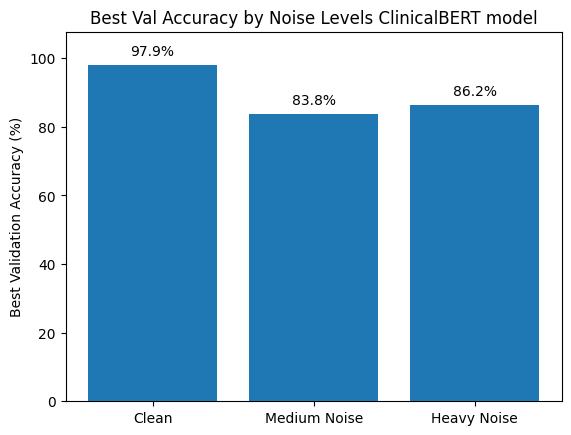

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

best_acc_by_level = {}
strict_gap = 0.05      # strict overfitting threshold (5%)
loose_gap  = 0.10      # looser overfitting threshold (10%)
max_train_acc = 0.95   # maximum allowed train accuracy for loose gap

for level, val_list in val_acc_history2.items():
    train_list = train_acc_history2[level]
    # compute (train_acc − val_acc) per epoch
    gaps = [t - v for t, v in zip(train_list, val_list)]
    # select epochs where gap ≤ strict_gap,
    # or gap ≤ loose_gap AND train_acc ≤ max_train_acc
    candidates = [
        i for i, (g, t) in enumerate(zip(gaps, train_list))
        if (g <= strict_gap) or (g <= loose_gap and t <= max_train_acc)
    ]
    if not candidates:
        # fallback to all epochs if none meet criteria
        candidates = list(range(len(val_list)))
    # pick the candidate epoch with highest val_acc
    best_idx = max(candidates, key=lambda i: val_list[i])
    best_acc_by_level[level] = val_list[best_idx] * 100

# plotting the results
labels = list(best_acc_by_level.keys())
values = list(best_acc_by_level.values())

fig, ax = plt.subplots()
bars = ax.bar(labels, values)

# annotate each bar with its value above the bar
for bar, v in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + (max(values) * 0.02),
        f"{v:.1f}%",
        ha='center',
        va='bottom',
        zorder=3
    )

ax.margins(y=0.1)
for spine in ax.spines.values():
    spine.set_zorder(0)
ax.set_ylim(0, None)
ax.set_ylabel("Best Validation Accuracy (%)")
ax.set_title("Best Val Accuracy by Noise Levels ClinicalBERT model")

plt.show()


## FLAN-T5 (Text-to-Text) Model with Adafactor Optimizer
This section focuses on fine-tuning the FLAN-T5 text-to-text generation model to classify patient symptoms under varying noise conditions. FLAN-T5 reformulates the classification task into a text-to-text format, providing robustness and flexibility in handling complex, noisy textual data.

Main features:

* FLAN-T5 text-to-text architecture (from Google).
* Adafactor optimizer designed specifically for transformer-based models.
* Specialized tokenization strategy for transforming classification into text-to-text.
* Explicit accuracy tracking on generated text tokens.



### Model and Configuration
Load tokenizer and initialize FLAN-T5

In [ ]:
import os
import numpy as np
import torch
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    T5ForConditionalGeneration,
    Adafactor
)
from sklearn.metrics import accuracy_score
from torch.utils.data import DataLoader

# Configuration
MODEL_NAME     = "google/flan-t5-base"
device         = "cuda" if torch.cuda.is_available() else "cpu"
tokenizer      = AutoTokenizer.from_pretrained(MODEL_NAME)
NUM_LABELS     = df["label"].nunique()
checkpoint_dir = "checkpoints_flan_t5"
os.makedirs(checkpoint_dir, exist_ok=True)

### Utility Functions & Training Configuration & Training and Evaluation Loop

In [ ]:
# Utility functions
def tokenize_batch(batch):
    # Tokenize inputs and labels for T5
    inputs = tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=512
    )
    targets = tokenizer(
        batch["label_text"],
        truncation=True,
        padding="max_length",
        max_length=4
    )
    inputs["labels"] = targets["input_ids"]
    return inputs

def compute_accuracy(preds, labels):
    # Compute accuracy on the first target token
    return (preds == labels).mean()

# Noise levels configuration
noise_levels = {
    "Clean": {"col": "text", "epochs": 9},
    "Medium Noise": {"col": "medium_noise", "epochs": 9},
    "Heavy Noise":  {"col": "heavy_noise",  "epochs": 10},
}

# dicts to store histories and final accuracies
train_acc_history3 = {}
val_acc_history3 = {}

# Main training loop
for level_name, settings in noise_levels.items():
    col_name   = settings["col"]
    num_epochs = settings["epochs"]
    batch_size = 8

    # lists to collect accuracies this run
    train_list3 = []
    val_list3 = []

    print(f"\n=== Flan-T5+Adafactor ({level_name}) | Epochs: {num_epochs} ===")

    # Prepare train/test DataFrames, add label_text column
    df_tr = df.loc[X_train_idx, [col_name, "label"]].rename(columns={col_name: "text"}).copy()
    df_te = df.loc[X_test_idx,  [col_name, "label"]].rename(columns={col_name: "text"}).copy()
    df_tr["label_text"] = df_tr["label"].astype(int).astype(str)
    df_te["label_text"] = df_te["label"].astype(int).astype(str)

    # Create Dataset & tokenize
    ds_tr = Dataset.from_pandas(df_tr, preserve_index=False).map(tokenize_batch, batched=True)
    ds_te = Dataset.from_pandas(df_te, preserve_index=False).map(tokenize_batch, batched=True)
    ds_tr.set_format("torch", columns=["input_ids", "attention_mask", "labels"])
    ds_te.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

    # DataLoaders
    train_loader = DataLoader(ds_tr, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(ds_te, batch_size=batch_size, shuffle=False)

    # Initialize model
    model = T5ForConditionalGeneration.from_pretrained(MODEL_NAME).to(device)

    # Initialize Adafactor optimizer with automatic warmup & lr
    optimizer = Adafactor(
        model.parameters(),
        relative_step=True,
        scale_parameter=True,
        warmup_init=True,
        weight_decay=0.01
    )

    # Training loop
    for epoch in range(1, num_epochs + 1):
        # Training phase
        model.train()
        train_preds, train_labels = [], []
        for batch in train_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(
                input_ids=batch["input_ids"],
                attention_mask=batch["attention_mask"],
                labels=batch["labels"]
            )
            loss   = outputs.loss
            logits = outputs.logits  # [B, T, V]

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            last_train_loss = loss.item()
            pred_ids = torch.argmax(logits[:, 0, :], dim=-1)
            train_preds.extend(pred_ids.cpu().numpy())
            train_labels.extend(batch["labels"][:, 0].cpu().numpy())

        train_acc = compute_accuracy(np.array(train_preds), np.array(train_labels))
        train_list3.append(train_acc)

        # Evaluation phase
        model.eval()
        val_preds, val_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                batch   = {k: v.to(device) for k, v in batch.items()}
                outputs = model(
                    input_ids=batch["input_ids"],
                    attention_mask=batch["attention_mask"],
                    labels=batch["labels"]
                )
                last_val_loss = outputs.loss.item()
                logits        = outputs.logits
                pred_ids      = torch.argmax(logits[:, 0, :], dim=-1)

                val_preds.extend(pred_ids.cpu().numpy())
                val_labels.extend(batch["labels"][:, 0].cpu().numpy())

        val_acc = compute_accuracy(np.array(val_preds), np.array(val_labels))
        val_list3.append(val_acc)

        # Print metrics
        print(
            f"Epoch {epoch}/{num_epochs} - "
            f"loss: {last_train_loss:.4f} - "
            f"acc: {train_acc:.4f} - "
            f"val_loss: {last_val_loss:.4f} - "
            f"val_acc: {val_acc:.4f}"
        )

        # Save checkpoint
        safe_level = level_name.replace(" ", "_").lower()
        ckpt_path  = os.path.join(
            checkpoint_dir,
            f"flant5_{safe_level}_epoch{epoch}.pt"
        )
        torch.save(model.state_dict(), ckpt_path)

    # store histories
    train_acc_history3[level_name] = train_list3
    val_acc_history3[level_name]   = val_list3

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

...

Map:   0%|          | 0/240 [00:00<?, ? examples/s]

Epoch 1/9 - loss: 2.8339 - acc: 0.0177 - val_loss: 2.4489 - val_acc: 0.0583
Epoch 2/9 - loss: 0.7684 - acc: 0.0448 - val_loss: 0.8094 - val_acc: 0.1583
Epoch 3/9 - loss: 0.4298 - acc: 0.3583 - val_loss: 0.2458 - val_acc: 0.6875
Epoch 4/9 - loss: 0.1484 - acc: 0.6979 - val_loss: 0.0079 - val_acc: 0.8167
Epoch 5/9 - loss: 0.2385 - acc: 0.8042 - val_loss: 0.0237 - val_acc: 0.8667
Epoch 6/9 - loss: 0.1562 - acc: 0.8885 - val_loss: 0.0759 - val_acc: 0.8833
Epoch 7/9 - loss: 0.0511 - acc: 0.9281 - val_loss: 0.0167 - val_acc: 0.9000
Epoch 8/9 - loss: 0.0306 - acc: 0.9510 - val_loss: 0.0786 - val_acc: 0.8625
Epoch 9/9 - loss: 0.0005 - acc: 0.9500 - val_loss: 0.2632 - val_acc: 0.9250

=== Flan-T5+Adafactor (Heavy Noise) | Epochs: 10 ===


Map:   0%|          | 0/960 [00:00<?, ? examples/s]

Map:   0%|          | 0/240 [00:00<?, ? examples/s]

Epoch 1/10 - loss: 2.1888 - acc: 0.0187 - val_loss: 1.8740 - val_acc: 0.0333
Epoch 2/10 - loss: 0.8117 - acc: 0.0490 - val_loss: 0.7975 - val_acc: 0.0500
Epoch 3/10 - loss: 0.4433 - acc: 0.2833 - val_loss: 0.3598 - val_acc: 0.6750
Epoch 4/10 - loss: 0.2149 - acc: 0.6740 - val_loss: 0.3018 - val_acc: 0.8000
Epoch 5/10 - loss: 0.1644 - acc: 0.8135 - val_loss: 0.0394 - val_acc: 0.8542
Epoch 6/10 - loss: 0.2375 - acc: 0.8917 - val_loss: 0.0729 - val_acc: 0.8708
Epoch 7/10 - loss: 0.3040 - acc: 0.9146 - val_loss: 0.0767 - val_acc: 0.8667
Epoch 8/10 - loss: 0.0276 - acc: 0.9490 - val_loss: 0.2126 - val_acc: 0.8625
Epoch 9/10 - loss: 0.0065 - acc: 0.9417 - val_loss: 0.2967 - val_acc: 0.8583
Epoch 10/10 - loss: 0.0041 - acc: 0.9708 - val_loss: 0.0031 - val_acc: 0.8958


### Visualization and Model Selection
Select the optimal model based on minimal overfitting and visualize

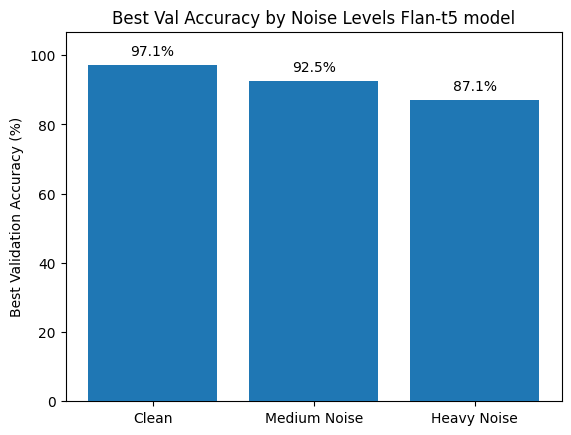

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

best_acc_by_level = {}
strict_gap = 0.05      # strict overfitting threshold (5%)
loose_gap  = 0.10      # looser overfitting threshold (10%)
max_train_acc = 0.95   # maximum allowed train accuracy for loose gap

for level, val_list in val_acc_history3.items():
    train_list = train_acc_history3[level]
    # compute (train_acc − val_acc) per epoch
    gaps = [t - v for t, v in zip(train_list, val_list)]
    # select epochs where gap ≤ strict_gap,
    # or gap ≤ loose_gap AND train_acc ≤ max_train_acc
    candidates = [
        i for i, (g, t) in enumerate(zip(gaps, train_list))
        if (g <= strict_gap) or (g <= loose_gap and t <= max_train_acc)
    ]
    if not candidates:
        # fallback to all epochs if none meet criteria
        candidates = list(range(len(val_list)))
    # pick the candidate epoch with highest val_acc
    best_idx = max(candidates, key=lambda i: val_list[i])
    best_acc_by_level[level] = val_list[best_idx] * 100

# plotting the results
labels = list(best_acc_by_level.keys())
values = list(best_acc_by_level.values())

fig, ax = plt.subplots()
bars = ax.bar(labels, values)

# annotate each bar with its value above the bar
for bar, v in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        v + (max(values) * 0.02),
        f"{v:.1f}%",
        ha='center',
        va='bottom',
        zorder=3
    )

ax.margins(y=0.1)
for spine in ax.spines.values():
    spine.set_zorder(0)
ax.set_ylim(0, None)
ax.set_ylabel("Best Validation Accuracy (%)")
ax.set_title("Best Val Accuracy by Noise Levels Flan-t5 model")

plt.show()